# Seller Level Master Table — Cleaning

## What is this notebook?
This notebook cleans `seller_level_master_table.csv`, which is a **seller-aggregated** table: one row per seller, summarizing all of that seller's activity across the whole e-commerce dataset (orders, items, sales, delivery performance, reviews). It was built earlier (see `data-processing-seller_master.ipynb`) by rolling up the raw `orders`, `order_items`, `order_payments`, `order_reviews`, and `sellers` datasets to the seller level.

This is different from the **master order table**, which is one row per order. Here, every row is one seller and the columns describe that seller's overall performance and behavior.

## What does the raw table contain?
3,095 sellers, 28 columns:

**Identity / location**
- `seller_id`, `seller_zip_code_prefix`, `seller_city`, `seller_state`

**Volume / catalog**
- `total_items_sold`, `unique_orders_from_items`, `unique_products_sold`, `category_diversity`, `orders_handled`, `unique_customers`

**Money**
- `total_item_sales_value`, `total_item_freight_value`, `avg_order_sales_value`, `avg_order_freight_value`, `avg_order_items`

**Activity window**
- `first_order_date`, `last_order_date`, `seller_tenure_days` (days between first and last order)

**Delivery performance**
- `late_delivery_orders`, `avg_delivery_delay_days` (negative = early, 0 = on time, positive = late), `avg_actual_delivery_days`, `late_delivery_rate`

**Reviews / risk**
- `avg_review_score`, `review_count`, `review_risk_orders`, `review_risk_rate`, `review_risk_flag` (True if review risk rate crosses a threshold)

**Status**
- `active_seller_flag` (True if seller is considered currently active)

## What did we do to it (summary)?
1. Profiled the raw data: shape, dtypes, summary stats, unique-value counts, and a missing-value report.
2. Found two genuine, explainable sources of missing values (not data errors):
   - `avg_review_score` is missing only when `review_count == 0` — the seller simply hasn't been reviewed yet.
   - `avg_delivery_delay_days` / `avg_actual_delivery_days` are missing when the seller has never had an order actually delivered to a customer, so there's no delivery date to compute delay from.
3. Unlike the order-level cleaning (where such rows were dropped because the *order* itself was unusable), here each row is a whole *seller* — dropping them would throw away otherwise valid, active sellers just because they haven't accumulated a review or a completed delivery yet. So instead of dropping, we **kept every seller** and added two boolean flags, `has_reviews` and `has_delivered_orders`, so downstream analysis can filter or segment on this explicitly while the underlying averages stay as `NaN` (never fabricated).
4. Converted `first_order_date` / `last_order_date` to proper datetimes and stripped whitespace from `seller_city` / `seller_state`.
5. Saved the result as `../data-visualization/cleaned_seller_level_master_table.csv` — same 3,095 sellers, 30 columns (28 original + `has_reviews` + `has_delivered_orders`).


In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("../data-visualization/seller_level_master_table.csv")
df

,seller_id,seller_zip_code_prefix,seller_city,seller_state,total_items_sold,unique_orders_from_items,unique_products_sold,category_diversity,total_item_sales_value,total_item_freight_value,...,avg_actual_delivery_days,avg_order_items,avg_order_sales_value,avg_order_freight_value,review_risk_orders,late_delivery_rate,review_risk_rate,seller_tenure_days,review_risk_flag,active_seller_flag
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,3,3,3,1,218.70,27.90,...,12.666667,1.000000,72.900000,9.30000,1,0.333333,0.333333,116,False,True
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,41,40,30,3,11703.07,1438.73,...,8.743590,1.025000,292.576750,35.96825,2,0.025000,0.050000,435,False,True
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,1,1,1,1,158.00,16.21,...,4.000000,1.000000,158.000000,16.21000,0,0.000000,0.000000,0,False,True
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,1,1,1,1,79.99,15.66,...,5.000000,1.000000,79.990000,15.66000,0,0.000000,0.000000,0,False,True
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,1,1,1,1,167.99,31.93,...,35.000000,1.000000,167.990000,31.93000,1,1.000000,1.000000,0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR,2,2,1,1,158.00,53.67,...,8.000000,1.000000,79.000000,26.83500,0,0.000000,0.000000,9,False,True
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC,10,10,4,1,889.00,255.83,...,12.700000,1.000000,88.900000,25.58300,1,0.100000,0.100000,420,False,True
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP,7,6,6,3,550.04,87.87,...,3.666667,1.166667,91.673333,14.64500,0,0.000000,0.000000,138,False,True
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS,11,8,1,0,297.00,185.47,...,5.714286,1.375000,37.125000,23.18375,1,0.000000,0.125000,129,False,True


In [3]:
df.shape

(3095, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   seller_id                 3095 non-null   object 
 1   seller_zip_code_prefix    3095 non-null   int64  
 2   seller_city               3095 non-null   object 
 3   seller_state              3095 non-null   object 
 4   total_items_sold          3095 non-null   int64  
 5   unique_orders_from_items  3095 non-null   int64  
 6   unique_products_sold      3095 non-null   int64  
 7   category_diversity        3095 non-null   int64  
 8   total_item_sales_value    3095 non-null   float64
 9   total_item_freight_value  3095 non-null   float64
 10  orders_handled            3095 non-null   int64  
 11  unique_customers          3095 non-null   int64  
 12  first_order_date          3095 non-null   object 
 13  last_order_date           3095 non-null   object 
 14  avg_revi

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,3442f8959a84dea7ee197c632cb2df15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,3095.0,NaN,NaN,NaN,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0
seller_city,3095,611,sao paulo,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3095,23,SP,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_items_sold,3095.0,NaN,NaN,NaN,36.397415,119.193461,1.0,2.0,8.0,24.0,2033.0
unique_orders_from_items,3095.0,NaN,NaN,NaN,32.313409,105.139763,1.0,2.0,6.0,21.5,1854.0
unique_products_sold,3095.0,NaN,NaN,NaN,11.13021,24.473252,1.0,2.0,4.0,10.0,399.0
category_diversity,3095.0,NaN,NaN,NaN,2.054604,2.098555,0.0,1.0,1.0,2.0,27.0
total_item_sales_value,3095.0,NaN,NaN,NaN,4391.484233,13921.997192,3.5,208.85,821.48,3280.83,229472.63
total_item_freight_value,3095.0,NaN,NaN,NaN,727.595974,2327.157672,6.66,46.17,155.52,558.17,51612.55


### Reading the exploration above
- `df.shape` / `df.info()` confirm 3,095 rows (sellers) and 28 raw columns, with dtypes mostly numeric except for `seller_id`, `seller_city`, `seller_state`, `first_order_date`, `last_order_date`.
- `df.describe(include="all").T` gives min/max/mean for every numeric column — useful to sanity check things like `avg_review_score` (should be 1–5) and rates (should be 0–1).
- `df.nunique().sort_values()` below shows which columns are near-constant (e.g. `seller_state` has ~23 values, boolean flags have 2) versus high-cardinality identifiers (`seller_id` is unique per row, as expected for a seller-level table).


In [6]:
df.nunique().sort_values()

active_seller_flag             1
review_risk_flag               2
category_diversity            21
seller_state                  23
late_delivery_orders          58
review_risk_orders            85
unique_products_sold         130
unique_customers             239
unique_orders_from_items     251
review_count                 251
orders_handled               251
total_items_sold             257
late_delivery_rate           409
review_risk_rate             478
avg_order_items              519
seller_tenure_days           586
seller_city                  611
avg_review_score             759
avg_actual_delivery_days    1327
avg_delivery_delay_days     1384
seller_zip_code_prefix      2246
avg_order_sales_value       2723
total_item_sales_value      2772
avg_order_freight_value     2889
total_item_freight_value    2923
last_order_date             3073
first_order_date            3094
seller_id                   3095
dtype: int64

In [7]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_summary

,missing_count,missing_pct
avg_actual_delivery_days,125,4.038772
avg_delivery_delay_days,125,4.038772
avg_review_score,5,0.161551
seller_zip_code_prefix,0,0.000000
review_risk_flag,0,0.000000
seller_tenure_days,0,0.000000
review_risk_rate,0,0.000000
late_delivery_rate,0,0.000000
review_risk_orders,0,0.000000
avg_order_freight_value,0,0.000000


In [8]:
df["seller_id"].duplicated().sum()

0

In [9]:
df["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
AC       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

## Understanding the missing values
- `avg_review_score` is missing exactly when `review_count` is 0, i.e. the seller has never received a review. There is no valid score to impute (mean/mode would fabricate a rating), so these are genuine "no review yet" sellers, not bad data.
- `avg_delivery_delay_days` and `avg_actual_delivery_days` are missing when none of the seller's orders were ever delivered to the customer (no delivery date exists to compute delay/actual days from), same reasoning as the master order table cleaning.

In [10]:
df[df["avg_review_score"].isna()][["seller_id", "review_count", "avg_review_score"]]

,seller_id,review_count,avg_review_score
953,bcd2d7510d58e293f20fad6438c1b314,0,NaN
1236,3820c6537b3853be1a0687d5a60807ec,0,NaN
1982,20f0aeea30bc3b8c4420be8ced4226c0,0,NaN
2120,400f221ab83037c0ea78f1267da9624d,0,NaN
2916,80ceebb4ee9b31afb6c6a916a574a1e2,0,NaN


In [11]:
df[df["avg_delivery_delay_days"].isna()][["seller_id", "orders_handled", "late_delivery_orders"]].head()

,seller_id,orders_handled,late_delivery_orders
26,2078fe5066350e7d220c0ad3a3bbc6c1,1,0
69,5206cc4bc2297c833e6061c49bf9c43f,1,0
123,f9eda05b67bef472deaddbba84aca289,1,0
137,34aefe746cd81b7f3b23253ea28bef39,1,0
145,ffcfefa19b08742c5d315f2791395ee5,1,0


## Cleaning decisions
- `avg_review_score`: keep the row (the seller is still a real, active seller) but flag that no review exists yet instead of dropping the seller entirely. We add a `has_reviews` flag and leave `avg_review_score` as NaN so it isn't confused with a real average.
- `avg_delivery_delay_days` / `avg_actual_delivery_days`: these can't be confidently imputed since the underlying orders were never delivered. We add a `has_delivered_orders` flag and leave the values as NaN, consistent with how the master order table treated undelivered orders.

In [12]:
new_df = df.copy()

new_df["has_reviews"] = new_df["review_count"] > 0
new_df["has_delivered_orders"] = new_df["avg_delivery_delay_days"].notna()

In [13]:
date_cols = ["first_order_date", "last_order_date"]

for col in date_cols:
    new_df[col] = pd.to_datetime(new_df[col], errors="coerce")

In [14]:
for col in ["seller_city", "seller_state"]:
    new_df[col] = new_df[col].str.strip()

In [15]:
new_df.isna().sum()

seller_id                     0
seller_zip_code_prefix        0
seller_city                   0
seller_state                  0
total_items_sold              0
unique_orders_from_items      0
unique_products_sold          0
category_diversity            0
total_item_sales_value        0
total_item_freight_value      0
orders_handled                0
unique_customers              0
first_order_date              0
last_order_date               0
avg_review_score              5
review_count                  0
late_delivery_orders          0
avg_delivery_delay_days     125
avg_actual_delivery_days    125
avg_order_items               0
avg_order_sales_value         0
avg_order_freight_value       0
review_risk_orders            0
late_delivery_rate            0
review_risk_rate              0
seller_tenure_days            0
review_risk_flag              0
active_seller_flag            0
has_reviews                   0
has_delivered_orders          0
dtype: int64

In [16]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   seller_id                 3095 non-null   object        
 1   seller_zip_code_prefix    3095 non-null   int64         
 2   seller_city               3095 non-null   object        
 3   seller_state              3095 non-null   object        
 4   total_items_sold          3095 non-null   int64         
 5   unique_orders_from_items  3095 non-null   int64         
 6   unique_products_sold      3095 non-null   int64         
 7   category_diversity        3095 non-null   int64         
 8   total_item_sales_value    3095 non-null   float64       
 9   total_item_freight_value  3095 non-null   float64       
 10  orders_handled            3095 non-null   int64         
 11  unique_customers          3095 non-null   int64         
 12  first_order_date    

In [17]:
total_sellers = new_df["seller_id"].nunique()
active_sellers = new_df["active_seller_flag"].sum()
avg_rating = new_df["avg_review_score"].mean()
late_delivery_rate = new_df["late_delivery_rate"].mean() * 100
avg_sales_value = new_df["total_item_sales_value"].mean()

print("Total Sellers:", total_sellers)
print("Active Sellers:", active_sellers)
print("Average Rating:", avg_rating)
print("Average Late Delivery Rate %:", late_delivery_rate)
print("Average Total Item Sales Value:", avg_sales_value)

Total Sellers: 3095
Active Sellers: 3095
Average Rating: 3.9972416047327504
Average Late Delivery Rate %: 6.2322670498807895
Average Total Item Sales Value: 4391.484232633279


## Before saving — what changed vs. the raw file
- Rows: **3,095 → 3,095** (no sellers dropped).
- Columns: **28 → 30** (added `has_reviews`, `has_delivered_orders`).
- `avg_review_score`: still `NaN` for the 5 sellers with `review_count == 0` (now clearly flagged via `has_reviews = False`), everyone else unchanged.
- `avg_delivery_delay_days` / `avg_actual_delivery_days`: still `NaN` for the 125 sellers with no delivered orders (now flagged via `has_delivered_orders = False`), everyone else unchanged.
- `first_order_date` / `last_order_date`: now proper `datetime64` instead of strings.
- `seller_city` / `seller_state`: whitespace-stripped text.
- No duplicate `seller_id`s existed, so no deduplication was needed.


In [18]:
new_df.to_csv("../data-visualization/cleaned_seller_level_master_table.csv", index=False)

In [19]:
print("Shape of cleaned seller master table:", new_df.shape)
print("Saved as: ../data-visualization/cleaned_seller_level_master_table.csv")

Shape of cleaned seller master table: (3095, 30)
Saved as: ../data-visualization/cleaned_seller_level_master_table.csv


## Visualizing the cleaned data
A quick visual look at the cleaned seller table: seller distribution by state, sales value spread, review scores, delivery performance, and how the two new flags (`has_reviews`, `has_delivered_orders`) split the seller population.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


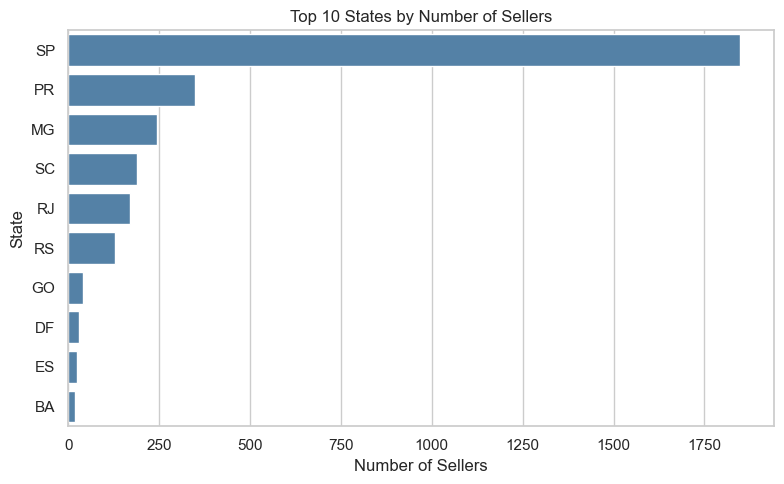

In [21]:
top_states = new_df["seller_state"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_states.values, y=top_states.index, color="steelblue")
plt.title("Top 10 States by Number of Sellers")
plt.xlabel("Number of Sellers")
plt.ylabel("State")
plt.tight_layout()
plt.show()


C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


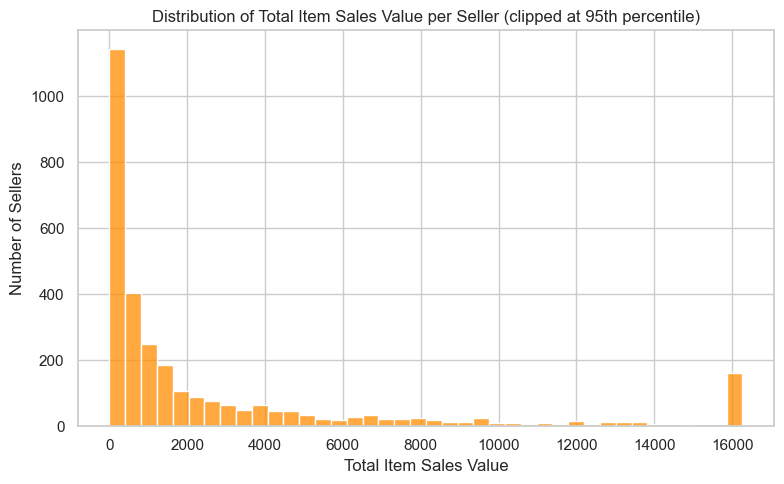

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(new_df["total_item_sales_value"].clip(upper=new_df["total_item_sales_value"].quantile(0.95)), bins=40, color="darkorange")
plt.title("Distribution of Total Item Sales Value per Seller (clipped at 95th percentile)")
plt.xlabel("Total Item Sales Value")
plt.ylabel("Number of Sellers")
plt.tight_layout()
plt.show()


C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


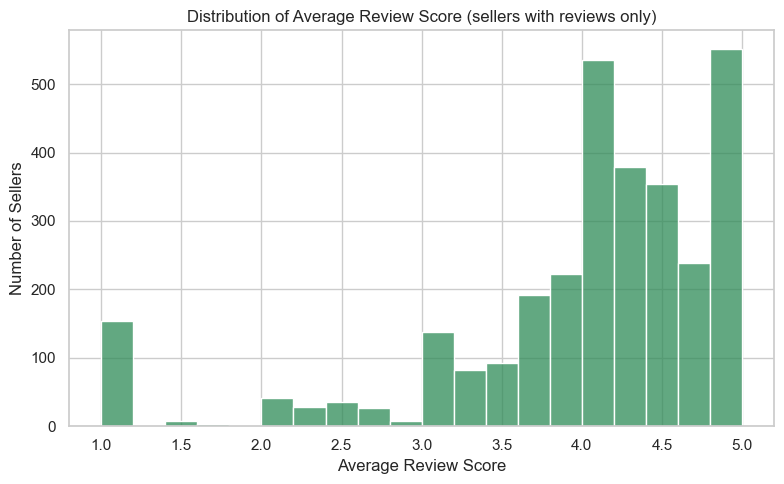

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(new_df.loc[new_df["has_reviews"], "avg_review_score"], bins=20, color="seagreen")
plt.title("Distribution of Average Review Score (sellers with reviews only)")
plt.xlabel("Average Review Score")
plt.ylabel("Number of Sellers")
plt.tight_layout()
plt.show()


C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


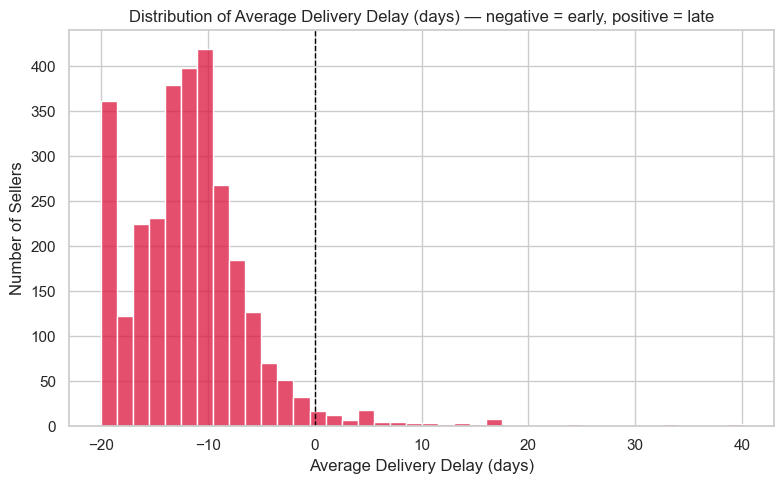

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(new_df.loc[new_df["has_delivered_orders"], "avg_delivery_delay_days"].clip(-20, 40), bins=40, color="crimson")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of Average Delivery Delay (days) — negative = early, positive = late")
plt.xlabel("Average Delivery Delay (days)")
plt.ylabel("Number of Sellers")
plt.tight_layout()
plt.show()


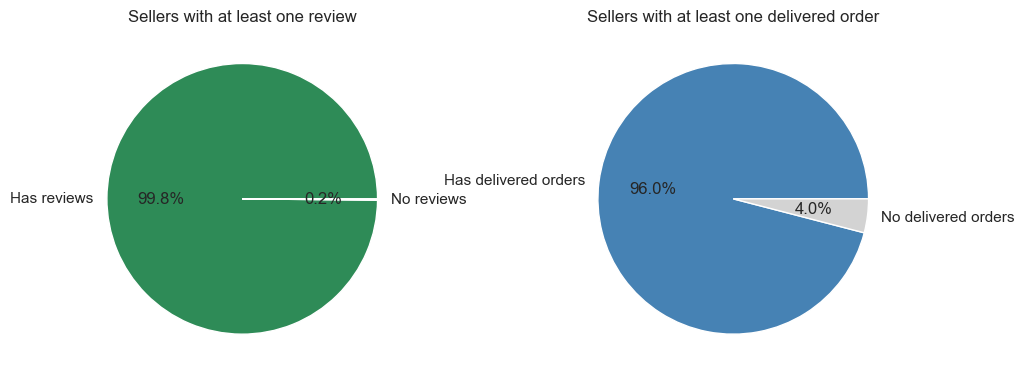

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

new_df["has_reviews"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[0], labels=["Has reviews", "No reviews"], colors=["seagreen", "lightgray"]
)
axes[0].set_ylabel("")
axes[0].set_title("Sellers with at least one review")

new_df["has_delivered_orders"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[1], labels=["Has delivered orders", "No delivered orders"], colors=["steelblue", "lightgray"]
)
axes[1].set_ylabel("")
axes[1].set_title("Sellers with at least one delivered order")

plt.tight_layout()
plt.show()


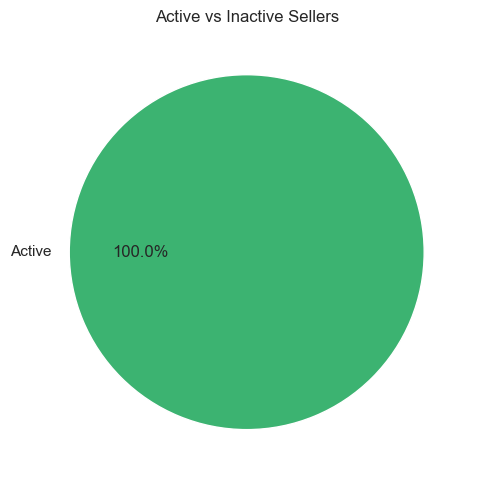

In [26]:
plt.figure(figsize=(5, 5))
new_df["active_seller_flag"].value_counts().plot.pie(
    autopct="%1.1f%%", labels=["Active", "Inactive"], colors=["mediumseagreen", "salmon"]
)
plt.ylabel("")
plt.title("Active vs Inactive Sellers")
plt.tight_layout()
plt.show()


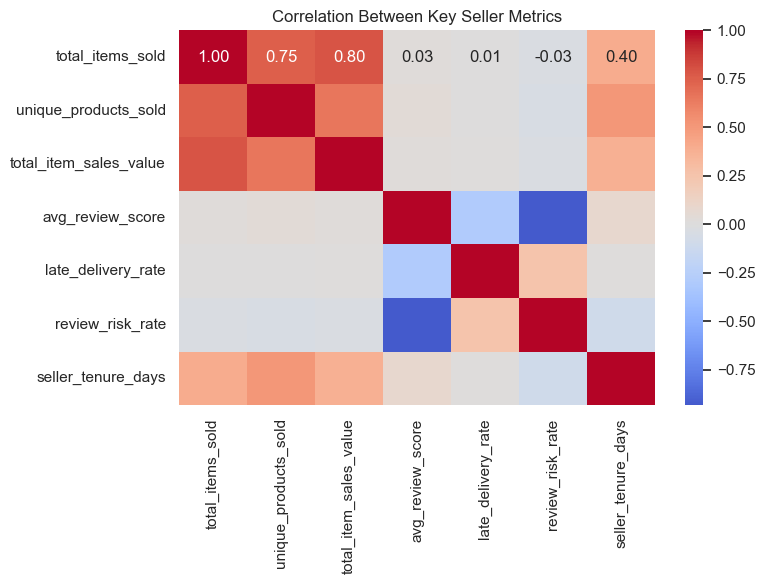

In [27]:
numeric_cols = [
    "total_items_sold", "unique_products_sold", "total_item_sales_value",
    "avg_review_score", "late_delivery_rate", "review_risk_rate", "seller_tenure_days"
]

plt.figure(figsize=(8, 6))
sns.heatmap(new_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Key Seller Metrics")
plt.tight_layout()
plt.show()
